In [1]:
import gymnasium as gym
import copy
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import rl_mind.envs
from dataclasses import dataclass, replace
from scipy import stats
from torch import Tensor
from torch.utils.tensorboard import SummaryWriter
from tqdm.auto import tqdm
from rl_mind.core import Action, Actor
from rl_mind.nn import build_mlp, soft_update
from rl_mind.env import VecEnv
from rl_mind.data import ReplayBuffer, Transitions
from rl_mind.collectors import TransitionCollector
from rl_mind.evaluation import Evaluator
from rl_mind.notebook import run_directory, setup_tensorboard, silence_known_warnings

from src.rl_miniproject_lunarlander import run_td3, run_ddpg, TD3Config, DDPGConfig, monte_carlo_Q, ForceInitialStateWrapper

In [ ]:
@dataclass(frozen=True)
class DDPG_custom_config(DDPGConfig):
    #Modifier comme on veut ici
    seed: int = 1
    
ddpg_cfg = DDPG_custom_config()
ddpg = run_ddpg(ddpg_cfg)

  0%|          | 0/30000 [00:00<?, ?it/s]

In [4]:
ddpg.visualize_best()

In [ ]:
@dataclass(frozen=True)
class TD3_custom_config(TD3Config):
    #Modifier comme on veut ici
    seed: int = 1

td3_cfg = TD3_custom_config()esti
td3 = run_td3(td3_cfg)

In [7]:
td3.visualize_best()

examples utilisation monte carlo

In [32]:
@dataclass(frozen=True)
class Config16(DDPGConfig):
    #Modifier comme on veut ici
    monte_carlo_n_envs : int = 16

cfg = Config16()

In [ ]:
forced_initial_env = VecEnv(
    env_name=cfg.env_name,
    num_envs=cfg.monte_carlo_n_envs,
    seed=cfg.monte_carlo_seed,
    wrappers=[ForceInitialStateWrapper,]
)

env = VecEnv(ddpg_cfg.env_name, 2, seed=1)
obs = env.reset()
actor=ddpg.best_actor

In [ ]:
monte_carlo_Q(forced_initial_env, obs[0], actor.act(obs)[0], actor, 10000, cfg.mc_n_episodes)


tensor(6.3120)
tensor(5.3379)


overestimation bias


In [2]:
@dataclass(frozen=True)
class DDPG_custom_config(DDPGConfig):
    seed: int = 1
    mc_interval: int = 2_000      # one check every 2000 env steps
    mc_n_samples: int = 10         # (s, a) pairs taken from the batch
    mc_n_episodes: int = 100      # rollouts per pair
    monte_carlo_n_envs: int = 16  # parallel envs for the rollouts

@dataclass(frozen=True)
class TD3_custom_config(TD3Config):
    seed: int = 1
    mc_interval: int = 2_000
    mc_n_samples: int = 10
    mc_n_episodes: int = 100
    monte_carlo_n_envs: int = 16

In [3]:
ddpg = run_ddpg(DDPG_custom_config())
td3 = run_td3(TD3_custom_config())

  0%|          | 0/30000 [00:00<?, ?it/s]

  0%|          | 0/30000 [00:00<?, ?it/s]

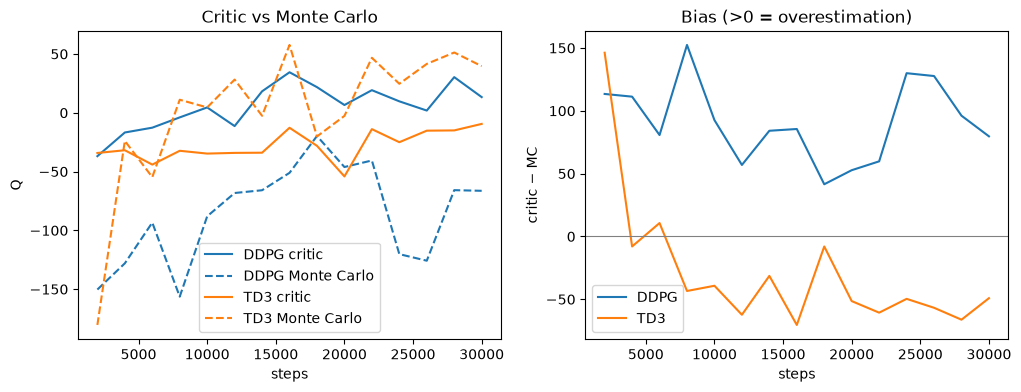

In [4]:
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator

def read_scalar(run_dir, tag):
    ea = EventAccumulator(str(run_dir)); ea.Reload()
    events = ea.Scalars(tag)
    return [e.step for e in events], [e.value for e in events]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for name, ev, critic in [("DDPG", ddpg, "critic"), ("TD3", td3, "critic_min")]:
    s, q = read_scalar(ev.run_dir, f"monte_carlo/q_{critic}")
    _, mc = read_scalar(ev.run_dir, "monte_carlo/q_mc")
    _, bias = read_scalar(ev.run_dir, f"monte_carlo/bias_{critic}")
    l, = ax1.plot(s, q, label=f"{name} critic")
    ax1.plot(s, mc, "--", color=l.get_color(), label=f"{name} Monte Carlo")
    ax2.plot(s, bias, label=name)
ax1.set(xlabel="steps", ylabel="Q", title="Critic vs Monte Carlo")
ax2.axhline(0, color="gray", lw=0.8)
ax2.set(xlabel="steps", ylabel="critic − MC", title="Bias (>0 = overestimation)")
ax1.legend(); ax2.legend()
